In [40]:
import argparse
import os
from typing import Union
from tqdm import tqdm
from glob import glob
import logging
import numpy as np
import scipy.io as sio
import torch
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
# import sys
# sys.path.insert(0, os.path.join(os.path.dirname(__file__), '..'))
# from deepsfp.config import config, update_config
# from deepsfp.utils import SfParser, setup_experiment

In [68]:
class TqdmLoggingHandler(logging.Handler):
    '''Helper to enable logging without interfering with TQDM progress bar. Credit: 
        https://stackoverflow.com/questions/38543506/change-logging-print-function-to-tqdm-write-so-logging-doesnt-interfere-wit/38739634#38739634'''
    
    def __init__(self, level=logging.NOTSET):
        super().__init__(level)

    def emit(self, record):
        try:
            msg = self.format(record)
            tqdm.tqdm.write(msg)
            self.flush()
        except Exception:
            self.handleError(record)

In [69]:
ROOT_DIR = '../DeepSfP/data/SurfaceNormals'
os.path.isdir(ROOT_DIR)

True

In [70]:
df = pl.read_csv(
    source=os.path.join(ROOT_DIR, 'train_list.csv'),
    has_header=False
).rename(
    mapping={
        'column_1': 'file_name'
        }
    )
print(df.shape, df.columns)
df.show()

(236, 1) ['file_name']


file_name
str
"""indoor/bird1_b.mat"""
"""indoor/bird1_f.mat"""
"""indoor/bird1_l.mat"""
"""indoor/bird1_r.mat"""
"""indoor/bird2_b.mat"""


In [71]:
dir(torch)

['AVG',
 'AcceleratorError',
 'AggregationType',
 'AliasDb',
 'AnyType',
 'Argument',
 'ArgumentSpec',
 'AwaitType',
 'BFloat16Storage',
 'BFloat16Tensor',
 'BenchmarkConfig',
 'BenchmarkExecutionStats',
 'Block',
 'BoolStorage',
 'BoolTensor',
 'BoolType',
 'BufferDict',
 'ByteStorage',
 'ByteTensor',
 'CallStack',
 'Capsule',
 'CharStorage',
 'CharTensor',
 'ClassType',
 'Code',
 'CompilationUnit',
 'CompleteArgumentSpec',
 'ComplexDoubleStorage',
 'ComplexFloatStorage',
 'ComplexType',
 'ConcreteModuleType',
 'ConcreteModuleTypeBuilder',
 'DeepCopyMemoTable',
 'DeserializationStorageContext',
 'DeviceObjType',
 'DictType',
 'DisableTorchFunction',
 'DisableTorchFunctionSubclass',
 'DispatchKey',
 'DispatchKeySet',
 'DoubleStorage',
 'DoubleTensor',
 'EnumType',
 'ErrorReport',
 'Event',
 'ExcludeDispatchKeyGuard',
 'ExecutionPlan',
 'FatalError',
 'FileCheck',
 'FloatStorage',
 'FloatTensor',
 'FloatType',
 'FunctionSchema',
 'Future',
 'FutureType',
 'Generator',
 'GradScaler',
 'G

In [72]:
PRECISION = np.float32

In [73]:
def to_tensor(arr, mask, precision=None):
    """
    Convert to Cx1024x1024 tensors consumable by model
    """
    arr = np.atleast_3d(arr)  # expand to 3d
    arr = arr * np.atleast_3d(mask)  # apply binary mask
    arr = arr[:, 100: 1124, :]  # remove padding
    arr = arr.transpose((2, 0, 1))  # transpose to CxHxW
    if not precision:
        precision = PRECISION
    arr = arr.astype(precision)  # convert precision
    arr = torch.from_numpy(arr)  # convert to tensor
    return arr

In [74]:
for i in range(123, df.shape[0]):
    file_path = os.path.join(ROOT_DIR, 'objects', df.item(i, 'file_name'))
    print(i, os.path.isfile(file_path))
    mat_file = sio.loadmat(file_path)
    mask = mat_file["mask"]
    sample = {
        "image": to_tensor(mat_file["images"], mask),
        # "est": to_tensor(mat_file["normals_prior"], mask),
        "label": to_tensor(mat_file["normals_gt"], mask),
        "mask": to_tensor(
            np.stack((mask, mask, mask), axis=2), mask, "uint8"
        ),
    }
    print(sample)
    break


123 True
{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0.,

In [54]:
sample["label"].shape

torch.Size([3, 1024, 1024])

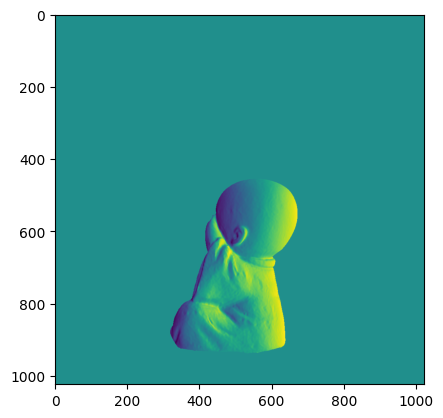

In [75]:
plt.imshow(sample["label"][0, :, :])

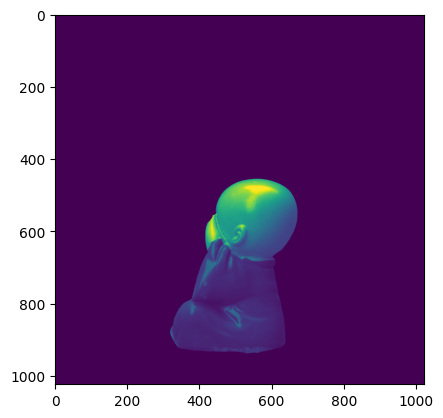

In [67]:
plt.imshow(sample["image"][0, :, :])

In [5]:
class DataConverter:
    def __init__(
        self,
        root: Union[str, os.PathLike],
        name: str,
        data_list: Union[str, os.PathLike],
        precision: Union[str, torch.dtype] = torch.float32,
        **kwargs,
    ):
        self._data_dir = os.path.join(root, name)
        self._data_list = data_list
        self._precision = precision

    def _toTensor(self, arr, mask, precision=None):
        """
        Convert to Cx1024x1024 tensors consumable by model
        """
        arr = np.atleast_3d(arr)  # expand to 3d
        arr = arr * np.atleast_3d(mask)  # apply binary mask
        arr = arr[:, 100:1124, :]  # remove padding
        arr = arr.transpose((2, 0, 1))  # transpose to CxHxW
        if not precision:
            precision = self._precision
        arr = arr.astype(self._precision)  # convert precision
        arr = torch.from_numpy(arr)  # convert to tensor
        return arr

    def __repr__(self):
        dataset = f"Dataset @ {self._data_dir}"
        objects = f"Objects in {self._data_list}"
        return f"DataConverter:\n\t{dataset}\n\t{objects}"

    def run(self, logger: logging.Logger, overwrite: bool = False, debug: bool = False):
        logger.info(f"Running {self}...")
        obj_dir = os.path.join(self._data_dir, "objects")
        mat_list = pd.read_csv(
            os.path.join(self._data_dir, self._data_list), header=None, squeeze=True
        )
        pth_list = mat_list.apply(lambda f: f"{os.path.splitext(f)[0]}.pth")
        filenames = zip(mat_list, pth_list)
        if not overwrite:
            filenames = filter(
                lambda mp: not os.path.exists(os.path.join(obj_dir, mp[-1])), filenames
            )
        pbar = tqdm(list(filenames))
        for i, (mat_path, pth_path) in enumerate(pbar):
            pbar.set_description(f"{mat_path} -> {pth_path}")
            logger.info(
                f"[{i + 1}/{len(pth_list)}] Converting {mat_path} -> {pth_path}..."
            )
            mat_file = sio.loadmat(os.path.join(obj_dir, mat_path))
            mask = mat_file["mask"]
            sample = {
                "image": self._toTensor(mat_file["images"], mask),
                "est": self._toTensor(mat_file["normals_prior"], mask),
                "label": self._toTensor(mat_file["normals_gt"], mask),
                "mask": self._toTensor(
                    np.stack((mask, mask, mask), axis=2), mask, "uint8"
                ),
            }
            if not debug:
                dest = os.path.join(obj_dir, pth_path)
                os.makedirs(os.path.dirname(dest), exist_ok=True)
                torch.save(sample, dest)
                logger.info(f"\tSaving to {os.path.realpath(dest)}")
